# Machine Learning Mini Project 1
##### Author: Donald Yeboah

Energy consumption is an important factor in ship operations. It directly affects operating cost and strongly impact environmental emissions. It is estimated a 50-60% of total voyage costs as fuel expenses, making it necessary for shipping companies to employ strategies that enhance fuel efficiency and reduce emissions. Being able to accurately predict fuel consumption is one of the effective ways to help ship operators improve their route planning, adjust speed and reduce unnecessary fuel usage.
This project aimed at building machine learning models that can predict the fuel consumption of the Danish ro-ro passenger ship using a given sensor data collected on board for a period time. Multiple machine learning algorithms are trained evaluated, with a target achieving at least 85% predictive accuracy.


##### Some practical notes to reproduce this work:
- This work uses only standard machine learning libraries; however, in case you run into any libarary compartibility issue, simple create a new virtual environment and install the packages (with the specific versions) from the requirements.txt file included (`pip install -r requirements.txt`)
- I also assume that the data files are in a subdirectory named `rawdata` within the project directory. If  this is not the case, ensure that you rename the subdirectory containing the data files appropriately, or, set the approrpiate directory name in the function that loads the data (`load_sensor`) 

I will:
1. Load raw sensor CSVs (each from different sensors, with different sampling rates).
2. Normalize timestamps (tick timestamps) and align sensors onto a unified timeline.
3. Build a physically meaningful target: fuel mass flow converted to **tons/sampling_rate**.
4. Create leakage-safe windowed features.
5. Train and compare **multiple ML models** with diagnostics.
6. Repeat the entire experiment for **three sampling rates** (`60ss`,  `300s` and `1800s` equivalent to  `1min`,  `5mins`, and  `30mins` respectively) and compare.


For ease of navigation, you can click on the following links to move directly to the corresponding section.
- [Import libraries](#import-libraries)
- [Data loading](#1-data-loading--preprocessing)
- [Exploratory data analysis](#2-lets-perform-a-quick-eda)
- [Aligning the timestamps and resampling](#3-alignment--resampling)
- [Creating the target variable](#4-target-construction)
- [Feature engineering](#5-feature-engineering-leakage-safe)
- [Spliting into Train-Val-Test Sets (time aware)](#6-time-aware-split)
- [Training different ML models to predict the fuel consumption](#7-lets-train-different-models-and-compare)
- [Training curves, learning curves, and loss curves](#8-curves-learning-curve--mlp-loss)
- [Feature importance](#9-feature-importance-interpretability)
- [Repeating for different sampling rates](#10-repeat-for-5-mins-300s-and-30-mins-1800s-sampling-and-compare)
- [Conclusion](#11-conclusions)


### Import libraries

In [1]:
import os, re, math
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import learning_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.inspection import permutation_importance
import warnings

pd.set_option("display.max_columns", 250)
pd.set_option("display.width", 140)
warnings.filterwarnings("ignore")

DATA_DIR = "rawdata"

WINDOW_SECONDS = 60          # rolling window used for feature engineering
TARGET_SMOOTH_SECONDS = 30   # smoothing for the target
RANDOM_STATE = 42


## 1) Data loading \& Preprocessing

Each CSV is a two-column time series saved **without headers**. Timestamps are stored as **ticks** (100ns) since 0001-01-01.

Let's create utilities to:
- read each sensor file reliably,
- convert ticks → UTC datetimes,
- parse latitude/longitude in `DDMM.MMMM[N|S]` / `DDDMM.MMMM[E|W]` format.


In [2]:
UNIX_EPOCH_TICKS = 621355968000000000  # ticks between 0001-01-01 and 1970-01-01
TICK_NS = 100  # 100ns per tick

def ticks_to_datetime_utc(ticks: pd.Series) -> pd.DatetimeIndex:
    ns_since_unix = (ticks.astype("int64") - UNIX_EPOCH_TICKS) * TICK_NS
    return pd.to_datetime(ns_since_unix, unit="ns", utc=True)

def read_two_col_sensor(path: str, value_name: str) -> pd.DataFrame:
    df = pd.read_csv(path, header=None, names=["ticks", value_name])
    df = df.dropna(subset=["ticks"])
    df["timestamp"] = ticks_to_datetime_utc(df["ticks"])
    df = df.drop(columns=["ticks"]).set_index("timestamp").sort_index()
    return df

_latlon_re = re.compile(r"^(?P<num>\d+(?:\.\d+)?)(?P<hem>[NSEW])$")

def parse_degmin_to_decimal(x: str) -> float:
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    m = _latlon_re.match(s)
    if not m:
        return np.nan
    num = float(m.group("num"))
    hem = m.group("hem")
    deg = int(num // 100)
    minutes = num - deg * 100
    dec = deg + minutes / 60.0
    if hem in ("S", "W"):
        dec *= -1
    return dec

def read_latlon_sensor(path: str, name: str) -> pd.DataFrame:
    df = pd.read_csv(path, header=None, names=["ticks", name])
    df["timestamp"] = ticks_to_datetime_utc(df["ticks"])
    df[name] = df[name].apply(parse_degmin_to_decimal).astype("float64")
    df = df.drop(columns=["ticks"]).set_index("timestamp").sort_index()
    return df


### Load provided sensors

In [3]:
paths = {
    "fuel_volume_flow_rate": os.path.join(DATA_DIR, "fuelVolumeFlowRate.csv"),
    "fuel_density": os.path.join(DATA_DIR, "fuelDensity.csv"),
    "fuel_temp": os.path.join(DATA_DIR, "fuelTemp.csv"),
    "wind_speed": os.path.join(DATA_DIR, "windSpeed.csv"),
    "wind_angle": os.path.join(DATA_DIR, "windAngle.csv"),
    "speed_kmh": os.path.join(DATA_DIR, "speedKmh.csv"),
    "speed_knots": os.path.join(DATA_DIR, "speedKnots.csv"),
    "port_rudder": os.path.join(DATA_DIR, "portRudder.csv"),
    "starboard_rudder": os.path.join(DATA_DIR, "starboardRudder.csv"),
    "port_pitch": os.path.join(DATA_DIR, "portPitch.csv"),
    "starboard_pitch": os.path.join(DATA_DIR, "starboardPitch.csv"),
    "inclinometer_raw": os.path.join(DATA_DIR, "inclinometer-raw.csv"),
    "true_heading": os.path.join(DATA_DIR, "trueHeading.csv"),
    "track_degree_true": os.path.join(DATA_DIR, "trackDegreeTrue.csv"),
    "track_degree_magnetic": os.path.join(DATA_DIR, "trackDegreeMagnetic.csv"),
    "latitude": os.path.join(DATA_DIR, "latitude.csv"),
    "longitude": os.path.join(DATA_DIR, "longitude.csv"),
    "level_1_median": os.path.join(DATA_DIR, "level1median.csv"),
    "level_2_median": os.path.join(DATA_DIR, "level2median.csv"),
    "longitudinal_water_speed": os.path.join(DATA_DIR, "longitudinalWaterSpeed.csv"),
}

sensors: Dict[str, pd.DataFrame] = {}
for key in [
    "fuel_volume_flow_rate","fuel_density","fuel_temp","wind_speed","wind_angle",
    "speed_kmh","speed_knots","port_rudder","starboard_rudder","port_pitch","starboard_pitch",
    "inclinometer_raw","true_heading","track_degree_true","track_degree_magnetic",
    "level_1_median","level_2_median","longitudinal_water_speed"
]:
    sensors[key] = read_two_col_sensor(paths[key], key)

sensors["latitude"] = read_latlon_sensor(paths["latitude"], "latitude")
sensors["longitude"] = read_latlon_sensor(paths["longitude"], "longitude")

pd.DataFrame({k: {"rows": len(v), "start": v.index.min(), "end": v.index.max()} for k,v in sensors.items()}).T.sort_values("rows", ascending=False)


,rows,start,end
level_1_median,3979774,2010-02-15 05:45:12.818414700+00:00,2010-04-12 22:25:15.661907700+00:00
level_2_median,3840794,2010-02-15 05:45:12.818414700+00:00,2010-04-12 22:25:14.328574500+00:00
inclinometer_raw,3559677,2010-02-15 05:45:13.092838+00:00,2010-04-12 22:25:16.240569+00:00
latitude,2677713,2010-02-15 05:45:13.770447+00:00,2010-04-12 22:25:16.327513+00:00
longitude,2677696,2010-02-15 05:45:13.770447+00:00,2010-04-12 22:25:16.327513+00:00
speed_knots,1766908,2010-02-15 05:45:13.069313+00:00,2010-04-12 22:25:16.469451+00:00
speed_kmh,1766906,2010-02-15 05:45:13.069313+00:00,2010-04-12 22:25:16.469451+00:00
track_degree_true,1766479,2010-02-15 05:45:13.916874+00:00,2010-04-12 22:25:16.469451+00:00
track_degree_magnetic,1766474,2010-02-15 05:45:13.916874+00:00,2010-04-12 22:25:16.469451+00:00
starboard_pitch,1726076,2010-02-15 05:45:13.558250+00:00,2010-04-12 22:25:15.832736+00:00


## 2) Let's Perform a Quick EDA

Inspect sampling cadence and plot a small raw slice.

In [4]:
def summarize_sensor(df: pd.DataFrame) -> dict:
    idx = df.index
    deltas = idx.to_series().diff().dropna().dt.total_seconds()
    return {
        "start": idx.min(),
        "end": idx.max(),
        "rows": len(df),
        "median_dt_sec": float(deltas.median()) if len(deltas) else np.nan,
    }

summary = pd.DataFrame({k: summarize_sensor(v) for k, v in sensors.items()}).T
summary.sort_values("median_dt_sec").head(15)


,start,end,rows,median_dt_sec
level_2_median,2010-02-15 05:45:12.818414700+00:00,2010-04-12 22:25:14.328574500+00:00,3840794,0.333333
level_1_median,2010-02-15 05:45:12.818414700+00:00,2010-04-12 22:25:15.661907700+00:00,3979774,0.333333
inclinometer_raw,2010-02-15 05:45:13.092838+00:00,2010-04-12 22:25:16.240569+00:00,3559677,0.484746
latitude,2010-02-15 05:45:13.770447+00:00,2010-04-12 22:25:16.327513+00:00,2677713,0.834145
longitude,2010-02-15 05:45:13.770447+00:00,2010-04-12 22:25:16.327513+00:00,2677696,0.834157
speed_kmh,2010-02-15 05:45:13.069313+00:00,2010-04-12 22:25:16.469451+00:00,1766906,0.997458
speed_knots,2010-02-15 05:45:13.069313+00:00,2010-04-12 22:25:16.469451+00:00,1766908,0.997458
track_degree_magnetic,2010-02-15 05:45:13.916874+00:00,2010-04-12 22:25:16.469451+00:00,1766474,0.997476
track_degree_true,2010-02-15 05:45:13.916874+00:00,2010-04-12 22:25:16.469451+00:00,1766479,0.997476
starboard_pitch,2010-02-15 05:45:13.558250+00:00,2010-04-12 22:25:15.832736+00:00,1726076,1.000584


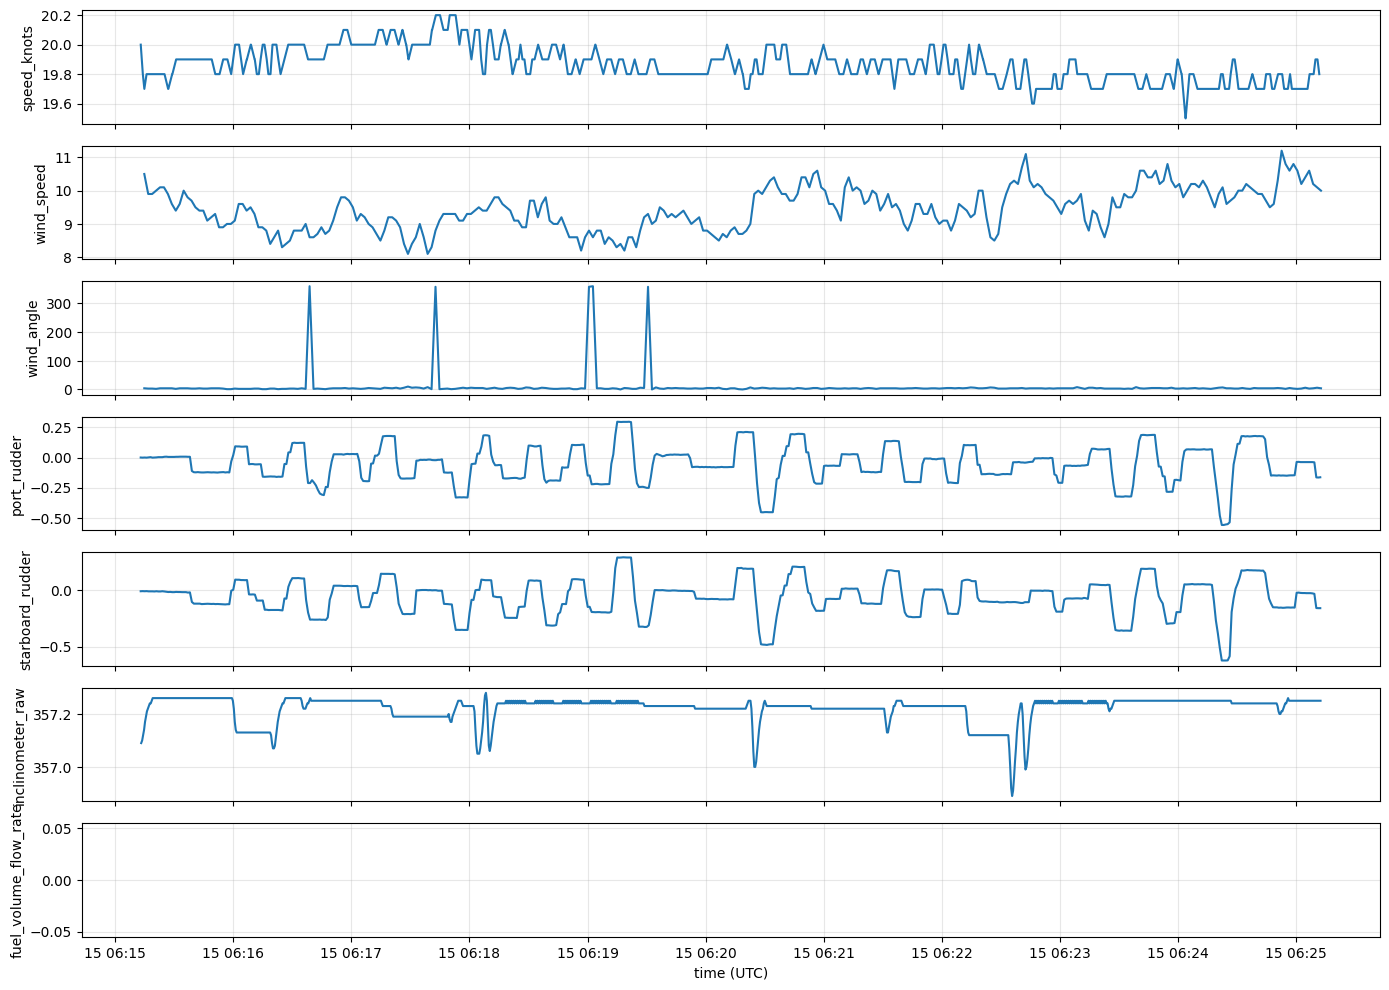

In [5]:
def plot_slice(sensors: Dict[str, pd.DataFrame], start=None, minutes=10):
    global_start = min(df.index.min() for df in sensors.values())
    if start is None:
        start = global_start + pd.Timedelta(minutes=30)
    end = start + pd.Timedelta(minutes=minutes)

    keys = ["speed_knots","wind_speed","wind_angle","port_rudder","starboard_rudder","inclinometer_raw","fuel_volume_flow_rate"]
    fig, axes = plt.subplots(len(keys), 1, figsize=(14, 10), sharex=True)
    for ax, k in zip(axes, keys):
        s = sensors[k].loc[start:end]
        ax.plot(s.index, s.iloc[:,0])
        ax.set_ylabel(k)
        ax.grid(True, alpha=0.3)
    axes[-1].set_xlabel("time (UTC)")
    plt.tight_layout()

plot_slice(sensors)


## 3) Alignment & resampling

 Align all sensors to a common timeline (e.g., `30s` or `60s`).

**Efficiency note:** the raw data can be millions of rows per sensor. We therefore:
- **resample each sensor first** to the desired frequency,
- then reindex to a shared master index,
- then time-interpolate short gaps.


In [6]:
def build_master_index_from_resampled(sensors, freq, required):
    # resample first to see where each sensor actually has data on that grid
    rs_min = []
    rs_max = []
    for k in required:
        rs = sensors[k].resample(freq).mean()
        first = rs.first_valid_index()
        last  = rs.last_valid_index()
        rs_min.append(first)
        rs_max.append(last)

    start = max(rs_min)
    end   = min(rs_max)
    return pd.date_range(start=start, end=end, freq=freq, tz="UTC")



def resample_to_index(df: pd.DataFrame, index: pd.DatetimeIndex, freq: str, limit_steps: int = 6) -> pd.DataFrame:
    # 1) resample to target frequency (mean is fine for most continuous signals)
    rs = df.resample(freq, origin=index[0]).mean()
    # 2) align to master index
    rs = rs.reindex(index)
    # 3) interpolate short gaps in *time* (limit in number of steps)
    rs = rs.interpolate(method="time", limit=limit_steps, limit_direction="both")
    return rs

def align_sensors(sensors: Dict[str, pd.DataFrame], freq: str) -> pd.DataFrame:
    required = ["fuel_volume_flow_rate","fuel_density","speed_knots","wind_speed","wind_angle","true_heading","latitude","longitude"]
    idx = build_master_index_from_resampled(sensors, freq=freq, required=required)

    aligned = []
    for name, df in sensors.items():
        col = df.columns[0]
        aligned.append(resample_to_index(df, idx, freq=freq).rename(columns={col: name}))
    return pd.concat(aligned, axis=1)
# Let's start with one minute sampling rate
X_60s = align_sensors(sensors, freq="60s")
X_60s.head()


,fuel_volume_flow_rate,fuel_density,fuel_temp,wind_speed,wind_angle,speed_kmh,speed_knots,port_rudder,starboard_rudder,port_pitch,starboard_pitch,inclinometer_raw,true_heading,track_degree_true,track_degree_magnetic,level_1_median,level_2_median,longitudinal_water_speed,latitude,longitude
2010-02-16 10:50:00+00:00,0.000000,0.947109,62.203645,12.800000,234.000000,0.000000,0.000000,0.088000,-0.050500,-0.039500,-0.036167,NaN,163.880000,353.000000,0.200000,15.062303,NaN,NaN,62.007228,-6.765462
2010-02-16 10:51:00+00:00,0.002686,0.947003,62.437674,12.821751,234.253531,0.021153,0.011373,0.076606,-0.013247,-0.033985,-0.020937,NaN,163.966058,351.865358,2.116205,15.077000,NaN,NaN,62.007227,-6.765466
2010-02-16 10:52:00+00:00,0.005372,0.946898,62.671702,12.843503,234.507062,0.042305,0.022746,0.065212,0.024006,-0.028470,-0.005707,NaN,164.052116,350.730716,4.032411,15.091697,NaN,NaN,62.007226,-6.765469
2010-02-16 10:53:00+00:00,0.008058,0.946792,62.905731,12.865254,234.760593,0.063458,0.034119,0.053818,0.061259,-0.022955,0.009523,NaN,164.138175,349.596074,5.948616,15.106393,NaN,NaN,62.007224,-6.765472
2010-02-16 10:54:00+00:00,0.010744,0.946687,63.139759,12.887006,235.014124,0.084610,0.045492,0.042424,0.098512,-0.017440,0.024754,NaN,164.224233,348.461432,7.864822,15.121090,NaN,NaN,62.007223,-6.765476


#### Inspecting usable rows since some rows have NaN due to the sampling

In [7]:
X_60s = align_sensors(sensors, freq="60s")

# 1) Any columns entirely NaN? (must be fixed or dropped)
all_nan_cols = X_60s.columns[X_60s.isna().all()]
print("All-NaN columns:", list(all_nan_cols))

# 2) Missingness rate per column (see if something is mostly missing)
missing_rate = X_60s.isna().mean().sort_values(ascending=False)
print(missing_rate.head(10))

# 3) Rows where required columns are all present (this matters for modeling)
required = ["fuel_volume_flow_rate","fuel_density","speed_knots","wind_speed","wind_angle","true_heading","latitude","longitude"]
usable = X_60s.dropna(subset=required)
print("Usable rows:", len(usable), "out of", len(X_60s), "(", len(usable)/len(X_60s), ")")


All-NaN columns: []
fuel_volume_flow_rate       0.611132
fuel_density                0.611132
fuel_temp                   0.611132
level_2_median              0.609255
starboard_rudder            0.609042
port_rudder                 0.609042
port_pitch                  0.609042
starboard_pitch             0.609042
inclinometer_raw            0.608954
longitudinal_water_speed    0.608591
dtype: float64
Usable rows: 31064 out of 79896 ( 0.38880544708120557 )


## 4) Target construction 
#### I will try several sampling rates, at 60s, 5 mins (300s), 30 mins (1800s)

compute fuel consumption as:
- `mass_flow_kg_s = volume_flow_rate * fuel_density`
- `fuel_tons_per_sampling_r = mass_flow_kg_s * (sampling_r/60.0) * 3600 / 1000`

also apply light smoothing to reduce jitter.

In [8]:
def add_target(df: pd.DataFrame, smooth_seconds: int, freq: str) -> pd.DataFrame:
    out = df.copy()
    n_seconds = pd.Timedelta(freq).total_seconds() # we convert the frequency to seconds
    out["mass_flow_kg_s"] = out["fuel_volume_flow_rate"] * out["fuel_density"]
    out[f"fuel_tons_per_{freq}"] = out["mass_flow_kg_s"] * (n_seconds/3600.0) * 3600.0 / 1000.0

    step = pd.Timedelta(freq).total_seconds()
    win = max(1, int(round(smooth_seconds / step)))
    out[f"fuel_tons_per_{freq}_smooth"] = out[f"fuel_tons_per_{freq}"].rolling(win, min_periods=max(1, win//2)).median()
    return out

X_60s = add_target(X_60s, smooth_seconds=TARGET_SMOOTH_SECONDS, freq="60s")
X_60s[["fuel_tons_per_60s","fuel_tons_per_60s_smooth"]].describe()


,fuel_tons_per_60s,fuel_tons_per_60s_smooth
count,31069.000000,31069.000000
mean,0.030908,0.030908
std,0.008160,0.008160
min,0.000000,0.000000
25%,0.028537,0.028537
50%,0.034716,0.034716
75%,0.035900,0.035900
max,0.040029,0.040029


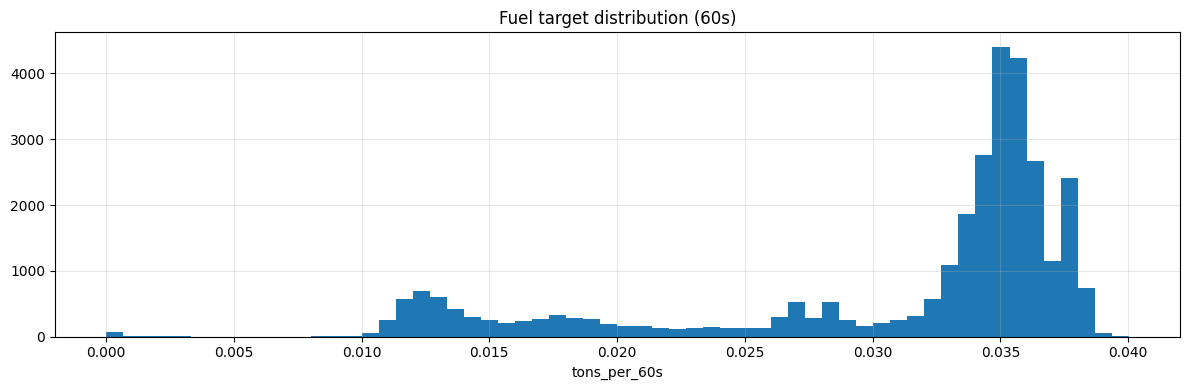

In [9]:
def plot_target(df: pd.DataFrame, title_suffix=""):
    s = df["fuel_tons_per_60s_smooth"].dropna()

    fig, ax = plt.subplots(figsize=(12,4))
    ax.hist(s, bins=60)
    ax.set_title(f"Fuel target distribution{title_suffix}")
    ax.set_xlabel("tons_per_60s")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # start = df.index.min() + pd.Timedelta(hours=2)
    # end = start + pd.Timedelta(minutes=40)
    # fig, ax = plt.subplots(figsize=(14,4))
    # ax.plot(df.loc[start:end].index, df.loc[start:end, "fuel_tons_per_day"], label="raw", alpha=0.6)
    # ax.plot(df.loc[start:end].index, df.loc[start:end, "fuel_tons_per_day_smooth"], label="smoothed", linewidth=2)
    # ax.set_title(f"Fuel target over time (slice){title_suffix}")
    # ax.set_ylabel("tons/day")
    # ax.grid(True, alpha=0.3)
    # ax.legend()
    # plt.tight_layout()
    # plt.show()

plot_target(X_60s, " (60s)")


## 5) Feature engineering (leakage-safe)

Generate windowed features (mean/std/min/max) and fast rolling slopes using convolution.
All rolling features use `t-1` and earlier values to avoid peeking.

also add:
- rudder/pitch deltas,
- GPS-derived speed (from lat/lon),
- angle sin/cos for circular variables,
- turn rates from headings/tracks.


In [10]:
def add_circular(df: pd.DataFrame, col: str) -> None:
    rad = np.deg2rad(df[col] % 360.0)
    df[f"{col}_sin"] = np.sin(rad)
    df[f"{col}_cos"] = np.cos(rad)

def haversine_m(lat1, lon1, lat2, lon2):
    R = 6371000.0
    phi1, phi2 = np.deg2rad(lat1), np.deg2rad(lat2)
    dphi = np.deg2rad(lat2 - lat1)
    dl = np.deg2rad(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dl/2)**2
    return 2*R*np.arcsin(np.sqrt(a))

def rolling_slope_fast(y: pd.Series, window: int) -> pd.Series:
    """Fast rolling slope for equally spaced samples using convolution.

    slope = sum((x-xm)*y)/sum((x-xm)^2)
    Handles NaNs by requiring a full non-NaN window.
    """
    arr = y.to_numpy(dtype=float)
    n = len(arr)
    out = np.full(n, np.nan, dtype=float)

    if window < 3 or window > n:
        return pd.Series(out, index=y.index)

    x = np.arange(window, dtype=float)
    w = x - x.mean()
    denom = (w**2).sum()

    valid = np.isfinite(arr).astype(float)
    arr0 = np.nan_to_num(arr, nan=0.0)

    numer = np.convolve(arr0, w[::-1], mode="valid")
    counts = np.convolve(valid, np.ones(window), mode="valid")

    slope_valid = np.where(counts == window, numer / denom, np.nan)
    out[window-1:] = slope_valid
    return pd.Series(out, index=y.index)

def build_features(df: pd.DataFrame, freq: str, window_seconds: int) -> Tuple[pd.DataFrame, pd.Series]:
    step = pd.Timedelta(freq).total_seconds()
    win = max(3, int(round(window_seconds / step)))

    base = df.copy()

    base["rudder_delta"] = base["port_rudder"] - base["starboard_rudder"]
    base["pitch_delta"] = base["port_pitch"] - base["starboard_pitch"]

    # GPS speed
    dist_m = haversine_m(base["latitude"].shift(1), base["longitude"].shift(1), base["latitude"], base["longitude"])
    base["gps_speed_m_s"] = dist_m / step
    base["gps_speed_knots"] = base["gps_speed_m_s"] * 1.943844

    def ang_diff(a, b):
        return (a - b + 180) % 360 - 180

    for col in ["true_heading","track_degree_true","track_degree_magnetic","wind_angle"]:
        base[f"{col}_diff_deg"] = ang_diff(base[col], base[col].shift(1))
        base[f"{col}_rate_deg_s"] = base[f"{col}_diff_deg"] / step
        add_circular(base, col)

    y = base[f"fuel_tons_per_{freq}_smooth"].copy()

    feats = base.drop(columns=["mass_flow_kg_s",f"fuel_tons_per_{freq}",f"fuel_tons_per_{freq}_smooth"])
    feats = feats.shift(1)  # leakage-safe: only past values

    # Rolling stats on a curated subset
    roll_cols = [
        "speed_knots","wind_speed","gps_speed_knots",
        "rudder_delta","pitch_delta","inclinometer_raw",
        "true_heading_rate_deg_s","track_degree_true_rate_deg_s","wind_angle_rate_deg_s",
    ]
    roll_cols = [c for c in roll_cols if c in feats.columns]

    for c in roll_cols:
        r = feats[c].rolling(win, min_periods=max(3, win//3))
        feats[f"{c}_roll_mean"] = r.mean()
        feats[f"{c}_roll_std"] = r.std()
        feats[f"{c}_roll_min"] = r.min()
        feats[f"{c}_roll_max"] = r.max()
        feats[f"{c}_roll_slope"] = rolling_slope_fast(feats[c], window=win)

    # A few lags (in steps)
    lags = sorted(set([1, int(round(5/step)), int(round(15/step))]))
    lags = [l for l in lags if l > 0]
    for c in ["speed_knots","wind_speed","gps_speed_knots","rudder_delta","pitch_delta","inclinometer_raw"]:
        if c not in feats.columns:
            continue
        for l in lags:
            feats[f"{c}_lag{l}"] = feats[c].shift(l)

    # Missingness flags
    for c in list(feats.columns):
        feats[f"{c}_isna"] = feats[c].isna().astype(int)

    return feats, y

X_feat_60s, y_60s = build_features(X_60s, freq="60s", window_seconds=WINDOW_SECONDS)
X_feat_60s.shape


(79896, 182)

## 6) Time-aware split

split chronologically into train/validation/test.

In [11]:
def time_split(X: pd.DataFrame, y: pd.Series, train_frac=0.70, val_frac=0.15):
    df = X.copy()
    df["target"] = y
    df = df.dropna(subset=["target"])
    n = len(df)
    n_train = int(n * train_frac)
    n_val = int(n * val_frac)
    train = df.iloc[:n_train]
    val = df.iloc[n_train:n_train+n_val]
    test = df.iloc[n_train+n_val:]
    return (
        (train.drop(columns=["target"]), train["target"]),
        (val.drop(columns=["target"]), val["target"]),
        (test.drop(columns=["target"]), test["target"]),
    )

(train_60s, val_60s, test_60s) = time_split(X_feat_60s, y_60s)
X_train_60s, y_train_60s = train_60s
X_val_60s, y_val_60s = val_60s
X_test_60s, y_test_60s = test_60s

X_train_60s.shape, X_val_60s.shape, X_test_60s.shape


((21748, 182), (4660, 182), (4661, 182))

## 7) Let's train different models and compare

Models:
- Ridge (we scale the data since it's important this kind of model)
- RandomForest
- HistGradientBoosting
- MLP (scaled, loss curve)


In [12]:
def fit_model(model, X_train, y_train, X_val, y_val, scale: bool):
    pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()) if scale else ("scaler", "passthrough"),
        ("model", model),
    ])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_val)
    return pipe, {
        "MAE": mean_absolute_error(y_val, pred),
        "RMSE": root_mean_squared_error(y_val, pred),
        "R2": r2_score(y_val, pred),
    }

def eval_model(pipe, X_test, y_test):
    pred = pipe.predict(X_test)
    return {
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": root_mean_squared_error(y_test, pred),
        "R2": r2_score(y_test, pred),
        "pred": pred,
    }

models = {
    "Ridge": (Ridge(alpha=2.0, random_state=RANDOM_STATE), True),
    "RandomForest": (RandomForestRegressor(n_estimators=250, min_samples_leaf=3, n_jobs=-1, random_state=RANDOM_STATE), False),
    "HistGB": (HistGradientBoostingRegressor(max_depth=6, learning_rate=0.05, max_iter=400, random_state=RANDOM_STATE), False),
    "MLP": (MLPRegressor(hidden_layer_sizes=(128,64), alpha=1e-4, learning_rate_init=1e-3, early_stopping=True, max_iter=200, random_state=RANDOM_STATE), True),
}

fitted_60s = {}
val_report_60s = {}
for name, (mdl, scale) in models.items():
    pipe, mets = fit_model(mdl, X_train_60s, y_train_60s, X_val_60s, y_val_60s, scale=scale)
    fitted_60s[name] = pipe
    val_report_60s[name] = mets

pd.DataFrame(val_report_60s).T.sort_values("RMSE")


,MAE,RMSE,R2
HistGB,0.000725,0.001499,0.961688
RandomForest,0.000679,0.001513,0.960946
MLP,0.000975,0.001761,0.947118
Ridge,0.001092,0.002217,0.916198


#### Let's run a test on the models trained

In [13]:
test_report_60s = {}
for name, pipe in fitted_60s.items():
    res = eval_model(pipe, X_test_60s, y_test_60s)
    test_report_60s[name] = {k: v for k, v in res.items() if k != "pred"}
pd.DataFrame(test_report_60s).T.sort_values("RMSE")


,MAE,RMSE,R2
RandomForest,0.000762,0.001626,0.958408
HistGB,0.000876,0.001651,0.957104
MLP,0.001145,0.001947,0.940367
Ridge,0.001255,0.002348,0.913250


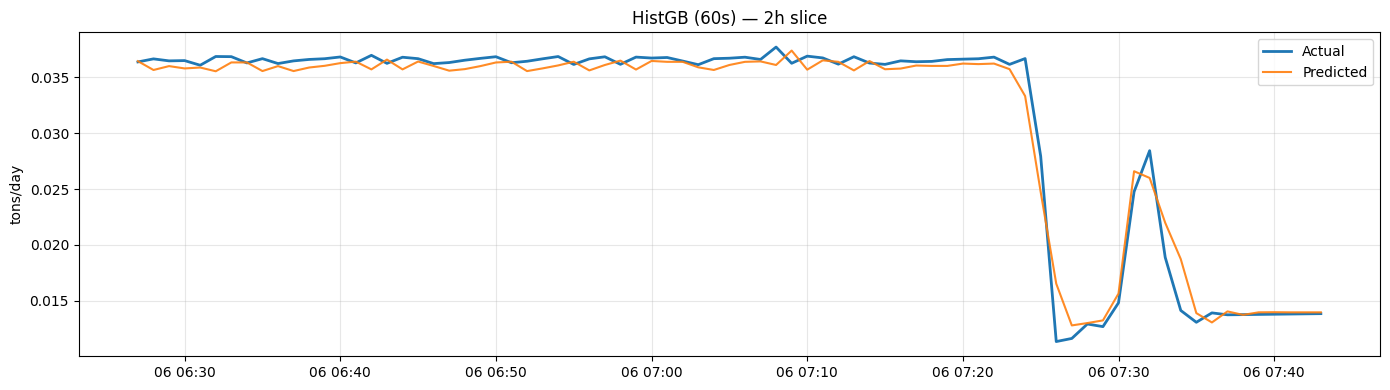

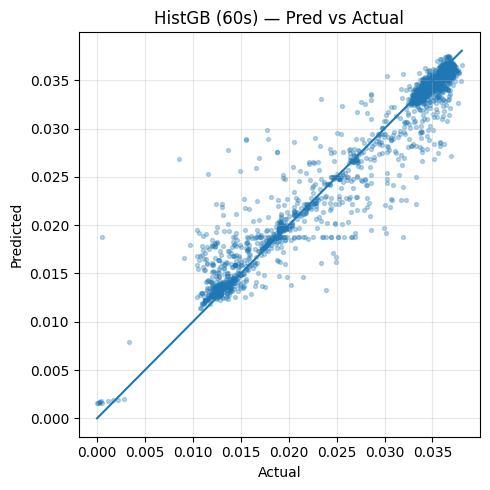

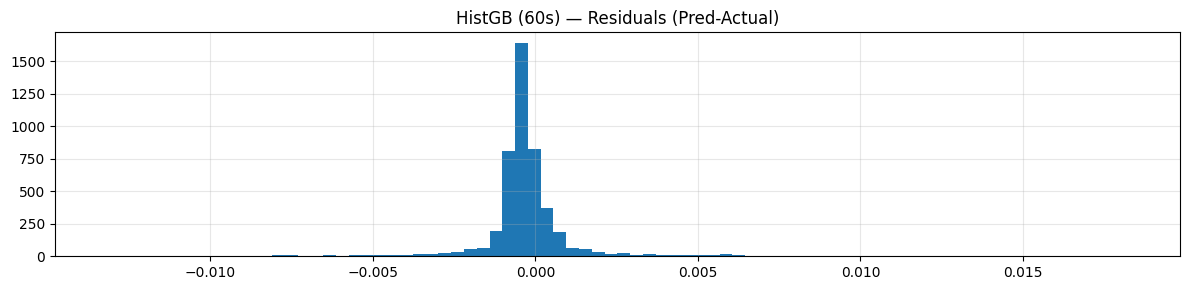

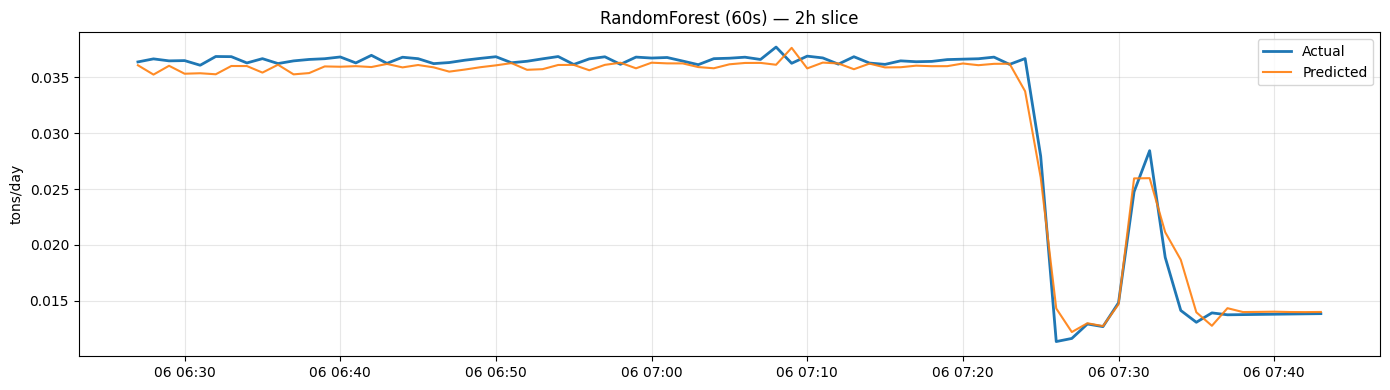

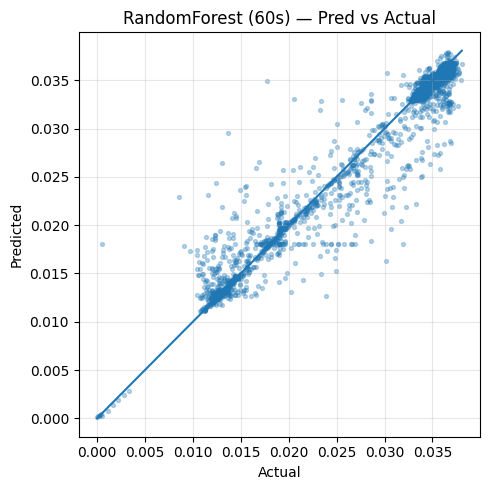

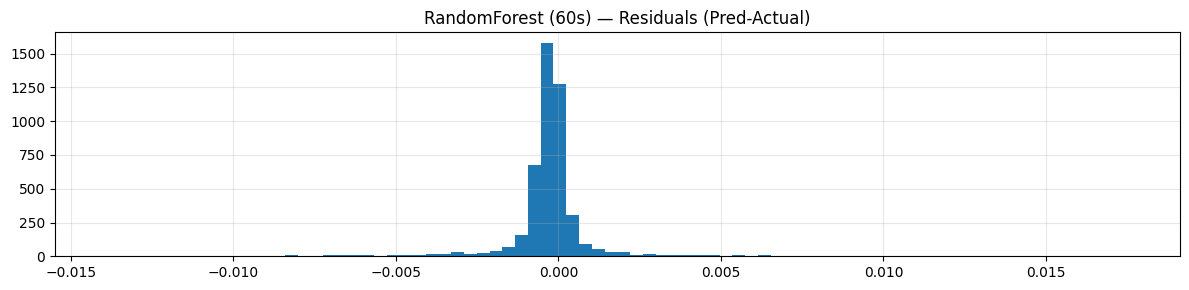

In [14]:
def plot_predictions(y_true: pd.Series, y_pred: np.ndarray, title: str):
    idx = y_true.index
    start = idx.min() + (idx.max() - idx.min()) * 0.10
    end = start + pd.Timedelta(hours=2)
    mask = (idx >= start) & (idx <= end)

    fig, ax = plt.subplots(figsize=(14,4))
    ax.plot(idx[mask], y_true.loc[mask], label="Actual", linewidth=2)
    ax.plot(idx[mask], y_pred[mask], label="Predicted", alpha=0.9)
    ax.set_title(f"{title} — 2h slice")
    ax.set_ylabel("tons/day")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(5,5))
    ax.scatter(y_true, y_pred, s=8, alpha=0.3)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims)
    ax.set_title(f"{title} — Pred vs Actual")
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    resid = y_pred - y_true.values
    fig, ax = plt.subplots(figsize=(12,3))
    ax.hist(resid, bins=80)
    ax.set_title(f"{title} — Residuals (Pred-Actual)")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

best_models = pd.DataFrame(val_report_60s).T.sort_values("RMSE").index[:2].tolist()
for name in best_models:
    pred = fitted_60s[name].predict(X_test_60s)
    plot_predictions(y_test_60s, pred, title=f"{name} (60s)")


## 8) Curves: learning curve + MLP loss

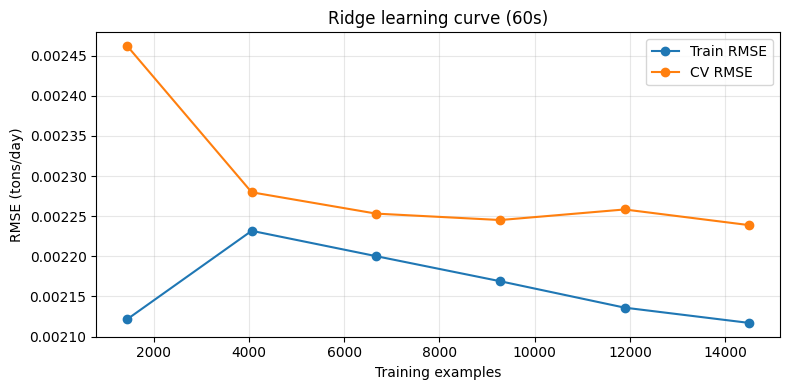

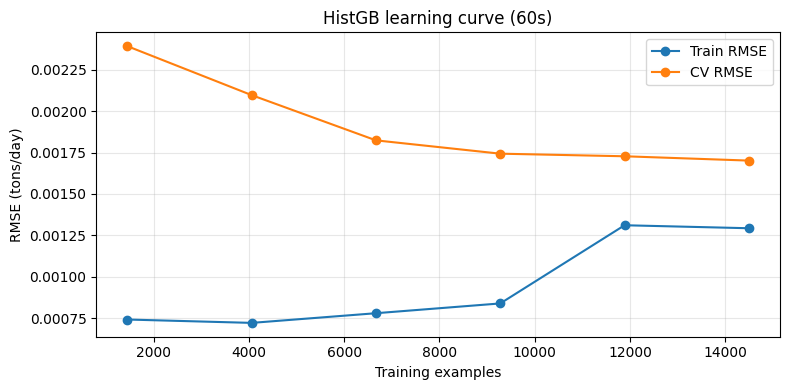

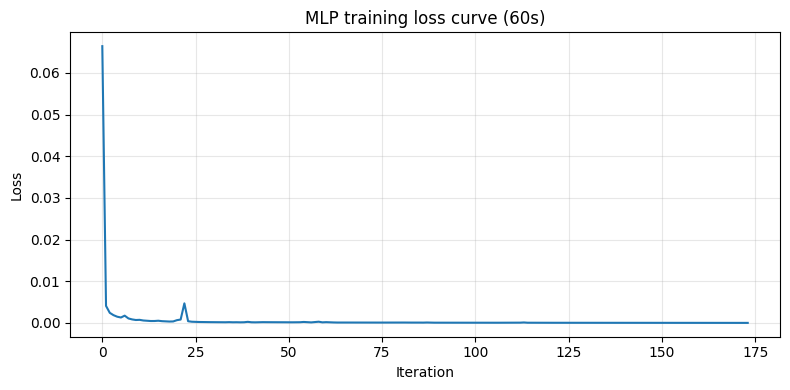

In [15]:
def plot_learning_curve(estimator, X, y, title: str):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X, y,
        train_sizes=np.linspace(0.1, 1.0, 6),
        cv=3,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
        shuffle=False,
    )
    train_rmse = -train_scores.mean(axis=1)
    val_rmse = -val_scores.mean(axis=1)

    fig, ax = plt.subplots(figsize=(8,4))
    ax.plot(train_sizes, train_rmse, marker="o", label="Train RMSE")
    ax.plot(train_sizes, val_rmse, marker="o", label="CV RMSE")
    ax.set_title(title)
    ax.set_xlabel("Training examples")
    ax.set_ylabel("RMSE (tons/day)")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

ridge_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=2.0, random_state=RANDOM_STATE)),
])
plot_learning_curve(ridge_pipe, X_train_60s, y_train_60s, "Ridge learning curve (60s)")

hgb_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", HistGradientBoostingRegressor(max_depth=6, learning_rate=0.05, max_iter=400, random_state=RANDOM_STATE)),
])
plot_learning_curve(hgb_pipe, X_train_60s, y_train_60s, "HistGB learning curve (60s)")

mlp = fitted_60s["MLP"].named_steps["model"]
if hasattr(mlp, "loss_curve_"):
    fig, ax = plt.subplots(figsize=(8,4))
    ax.plot(mlp.loss_curve_)
    ax.set_title("MLP training loss curve (60s)")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Loss")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## 9) Feature importance (interpretability)

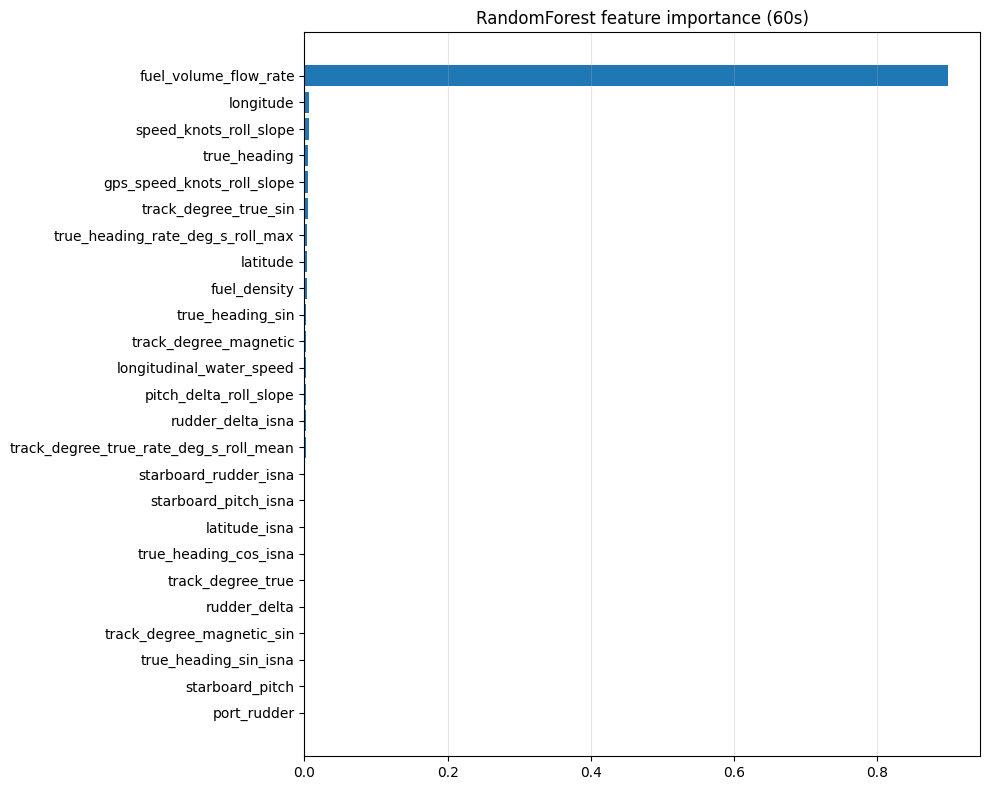

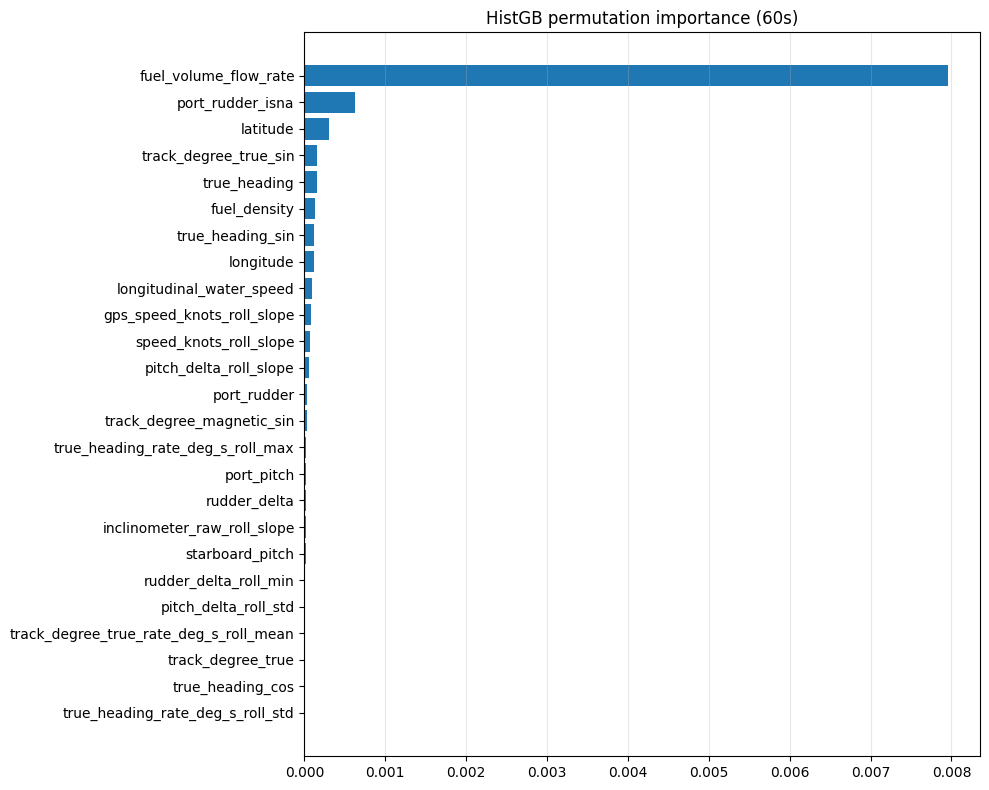

In [16]:
def plot_top_importances(names, importances, title, top_n=25):
    s = pd.Series(importances, index=names).sort_values(ascending=False).head(top_n)[::-1]
    fig, ax = plt.subplots(figsize=(10,8))
    ax.barh(s.index, s.values)
    ax.set_title(title)
    ax.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

rf = fitted_60s["RandomForest"].named_steps["model"]
plot_top_importances(X_train_60s.columns, rf.feature_importances_, "RandomForest feature importance (60s)")

perm = permutation_importance(fitted_60s["HistGB"], X_val_60s, y_val_60s, n_repeats=4, random_state=RANDOM_STATE, n_jobs=-1, scoring="neg_root_mean_squared_error")
plot_top_importances(X_val_60s.columns, perm.importances_mean, "HistGB permutation importance (60s)")


## 10) Repeat for 5 mins (300s) and 30 mins (1800s) sampling and compare

let's rerun alignment → target → features → modeling at `5s` and compare metrics side-by-side.

In [17]:
def run_experiment(freq: str) -> pd.DataFrame:
    X = align_sensors(sensors, freq=freq)
    X = add_target(X, smooth_seconds=TARGET_SMOOTH_SECONDS, freq=freq)
    X_feat, y = build_features(X, freq=freq, window_seconds=WINDOW_SECONDS)

    (train, val, test) = time_split(X_feat, y)
    X_train, y_train = train
    X_val, y_val = val
    X_test, y_test = test

    val_report = {}
    test_report = {}

    for name, (mdl, scale) in models.items():
        pipe, mets = fit_model(mdl, X_train, y_train, X_val, y_val, scale=scale)
        val_report[name] = mets
        test_report[name] = {k: v for k, v in eval_model(pipe, X_test, y_test).items() if k != "pred"}

    out = pd.DataFrame({
        "val_RMSE": {k: v["RMSE"] for k, v in val_report.items()},
        "val_MAE":  {k: v["MAE"] for k, v in val_report.items()},
        "val_R2":   {k: v["R2"] for k, v in val_report.items()},
        "test_RMSE": {k: v["RMSE"] for k, v in test_report.items()},
        "test_MAE":  {k: v["MAE"] for k, v in test_report.items()},
        "test_R2":   {k: v["R2"] for k, v in test_report.items()},
    }).sort_values("test_RMSE")
    out["freq"] = freq
    return out

report_60s = run_experiment("60s")
report_300s = run_experiment("300s")
report_1800s = run_experiment("1800s")

comparison = pd.concat([report_60s, report_300s, report_1800s])
comparison


,val_RMSE,val_MAE,val_R2,test_RMSE,test_MAE,test_R2,freq
RandomForest,0.001513,0.000679,0.960946,0.001626,0.000762,0.958408,60s
HistGB,0.001499,0.000725,0.961688,0.001651,0.000876,0.957104,60s
MLP,0.001761,0.000975,0.947118,0.001947,0.001145,0.940367,60s
Ridge,0.002217,0.001092,0.916198,0.002348,0.001255,0.913250,60s
HistGB,0.007895,0.003893,0.966553,0.009272,0.004541,0.952310,300s
RandomForest,0.008676,0.004134,0.959608,0.009823,0.004998,0.946473,300s
Ridge,0.014760,0.009684,0.883082,0.014316,0.009505,0.886307,300s
MLP,0.067282,0.046676,-1.429315,0.065977,0.045604,-1.414897,300s
RandomForest,0.096804,0.050571,0.766773,0.090129,0.048806,0.810273,1800s
HistGB,0.102434,0.052104,0.738857,0.095903,0.050782,0.785183,1800s


## 11) Conclusions



The results show that Histogram Gradient Boosting and Random Forest, achieved the best predictive performance. These models were able to exceed the required accuracy threshold and showed strong generalization on unseen data. Ridge Regression provided a useful baseline but could not fully capture nonlinear relationships. The Multi Layer Perceptron achieved good results but required more tuning and computational effort.